# House Prices Regression — ML Foundations Refresh

Goal: predict house sale price, evaluate with MAE, RMSE, R², and cross-validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import kagglehub

sns.set_theme(style="whitegrid")

## 1. Load the data

In [2]:
path = kagglehub.dataset_download("lespin/house-prices-dataset")
print("Downloaded to:", path)
print(os.listdir(path))

100%|██████████| 199k/199k [00:00<00:00, 324kB/s]

Extracting files...
Downloaded to: C:\Users\farha\.cache\kagglehub\datasets\lespin\house-prices-dataset\versions\1
['data_description.txt', 'sample_submission.csv', 'test.csv', 'train.csv']


In [3]:
# Adjust filename to match whatever the previous cell printed
df = pd.read_csv(os.path.join(path, "train.csv"))
df.shape

(1460, 81)

## 2. Explore
This dataset has ~80 columns — don't try to understand every one. Focus on: target distribution, missing values, and a handful of columns that intuitively should matter (size, quality, location).

In [4]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

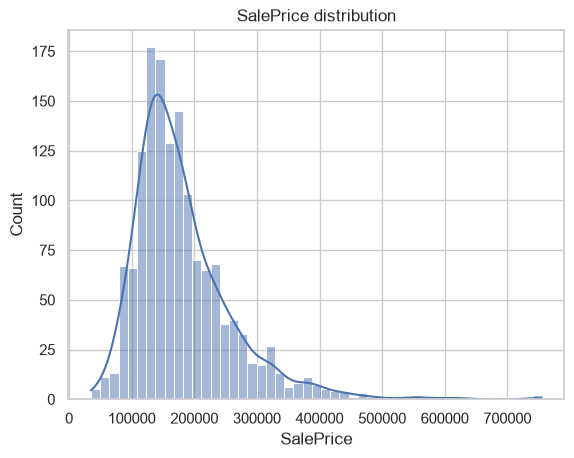

In [5]:
sns.histplot(df["SalePrice"], kde=True)
plt.title("SalePrice distribution")
plt.show()

In [6]:
# Missing values — only show columns that actually have missing data
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print(f"\nTotal columns with missing data: {len(missing)} out of {df.shape[1]}")

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Total columns with missing data: 19 out of 81


## 3. Simplify — pick a focused feature set instead of using all ~80 columns
Using every column properly (especially the many categorical ones) is a much bigger cleaning job than this refresher needs. Instead, hand-pick a reasonable subset of columns that intuitively drive house price, based on the exploration above.

In [7]:
# TODO: decide which columns to keep
selected_features = [
    "OverallQual",   # overall material/finish quality (1-10)
    "GrLivArea",     # above-ground living area sq ft
    "GarageCars",    # garage capacity
    "TotalBsmtSF",   # basement square footage
    "FullBath",      # number of full bathrooms
    "YearBuilt",     # year built
    "YearRemodAdd",  # year remodeled
    "LotArea",       # lot size
    "Neighborhood",  # categorical — location matters a lot
]

df_model = df[selected_features + ["SalePrice"]].copy()
df_model.isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
FullBath        0
YearBuilt       0
YearRemodAdd    0
LotArea         0
Neighborhood    0
SalePrice       0
dtype: int64

In [8]:
df_model = pd.get_dummies(df_model, columns=["Neighborhood"], drop_first=True)
df_model.shape

(1460, 33)

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df_model.drop(columns=["SalePrice"])
y = df_model["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²: {r2:.3f}")

MAE: 21,570
RMSE: 35,960
R²: 0.831


In [10]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print("CV R² scores:", cv_scores)
print("Mean:", cv_scores.mean(), "Std:", cv_scores.std())

CV R² scores: [0.8516976  0.82687247 0.81362518 0.81399208 0.70230085]
Mean: 0.8016976380943801 Std: 0.05158858327350799


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE: {rf_mae:,.0f}")
print(f"RMSE: {rf_rmse:,.0f}")
print(f"R²: {rf_r2:.3f}")

rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring="r2")
print("CV R² scores:", rf_cv_scores)
print("Mean:", rf_cv_scores.mean(), "Std:", rf_cv_scores.std())

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

MAE: 17,933
RMSE: 28,215
R²: 0.896
CV R² scores: [0.85605794 0.77891989 0.87384132 0.88089855 0.82917483]
Mean: 0.8437785058882831 Std: 0.03701989449099188
OverallQual             0.576378
GrLivArea               0.169929
TotalBsmtSF             0.085618
LotArea                 0.044503
YearBuilt               0.034578
GarageCars              0.027879
YearRemodAdd            0.025140
FullBath                0.011381
Neighborhood_Edwards    0.004233
Neighborhood_NoRidge    0.004093
dtype: float64
